# Tech Advertising Campaign Performance & ROI Analytics

## Project 3 — End-to-End Marketing Analytics

**Dataset:** Tech Advertising Campaigns  
**Tools:** Python, Pandas, NumPy, Matplotlib

### Objective
Analyze advertising campaign performance across platforms, campaign objectives, audiences, devices, placements, creatives, and time periods.

### Important
This notebook has been verified against the actual dataset and is designed to run without the categorical/numeric conversion error from the previous version.


## 1. LOAD DATA


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATHS = [
    Path("../data/tech_advertising_campaigns_dataset.csv"),
    Path("tech_advertising_campaigns_dataset.csv"),
    Path("/mnt/data/tech_advertising_campaigns_dataset.csv")
]
DATA_PATH = next((p for p in DATA_PATHS if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Dataset not found. Put 'tech_advertising_campaigns_dataset.csv' "
        "in the notebook folder, its data folder, or /mnt/data."
    )

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Dataset loaded: 10,000 rows × 41 columns


,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,creative_emotion,creative_age_days,target_audience_age,target_audience_gender,audience_interest_category,income_bracket,purchase_intent_score,retargeting_flag,start_date,quarter,day_of_week,hour_of_day,campaign_day,quality_score,actual_cpc,impressions,clicks,conversions,ad_spend,revenue,bounce_rate,avg_session_duration_seconds,pages_per_session,industry_vertical,budget_tier,CTR,CPC,conversion_rate,CPA,ROAS,profit
0,CAMP_00001,Lead Generation,Facebook,Search,Mobile,Android,Text,728x90,Short,False,Curiosity,72,45-54,Female,Shoppers,<$50K,Medium,False,2024-03-06,1,Wednesday,18,34,5,2.23,66329,402,2,896.46,289.67,67.75,70,2.00,E-commerce,High,0.61,2.23,0.50,448.23,0.32,-606.79
1,CAMP_00002,Engagement,Facebook,Feed,Mobile,iOS,Image,320x50,Long,True,Neutral,62,65+,Female,Business Professionals,$50K-$100K,Medium,False,2024-01-26,1,Friday,6,22,5,2.48,50094,467,5,"1,158.16","1,728.20",63.73,105,2.74,Finance,Medium,0.93,2.48,1.07,231.63,1.49,570.04
2,CAMP_00003,Conversions,Google Ads,Feed,Tablet,iOS,Video,1920x1080,Short,False,Urgency,79,65+,Male,Tech Enthusiasts,<$50K,High,False,2025-05-15,2,Thursday,1,32,4,3.88,10842,112,6,434.56,"2,903.26",31.93,149,3.97,Healthcare,Low,1.03,3.88,5.36,72.43,6.68,"2,468.70"
3,CAMP_00004,Conversions,LinkedIn,Search,Desktop,iOS,Carousel,1920x1080,Short,False,Joy,57,35-44,All,Shoppers,<$50K,Low,False,2024-07-21,3,Sunday,7,32,4,8.29,7820,123,3,"1,019.67",502.28,65.52,147,2.49,Education,Medium,1.57,8.29,2.44,339.89,0.49,-517.39
4,CAMP_00005,Brand Awareness,Facebook,Stories,Mobile,iOS,Image,1920x1080,Short,False,Joy,17,25-34,Female,Students,$100K-$200K,Low,False,2025-03-09,1,Sunday,17,52,7,1.41,21436,302,0,425.82,0.00,68.95,81,3.04,SaaS,Low,1.41,1.41,0.00,0.00,0.00,-425.82


## 2. DATA TYPES / DATE


In [2]:
if "start_date" in df.columns:
    df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")

# Keep the original columns. Create safe numeric copies only where needed.
numeric_candidates = [
    "impressions", "clicks", "conversions", "ad_spend", "revenue",
    "profit", "CTR", "CPC", "conversion_rate", "CPA", "ROAS",
    "bounce_rate", "quality_score", "purchase_intent_score",
    "avg_session_duration_seconds", "pages_per_session", "creative_age_days",
    "hour_of_day", "campaign_day"
]

numeric_cols = []
for col in numeric_candidates:
    if col in df.columns:
        converted = pd.to_numeric(df[col], errors="coerce")
        # Use the converted version only when the column is genuinely numeric.
        # Categorical columns such as purchase_intent_score remain categorical.
        if converted.notna().mean() >= 0.95:
            df[col] = converted
            numeric_cols.append(col)

print("\nNumeric columns safely detected:")
print(numeric_cols)



Numeric columns safely detected:
['impressions', 'clicks', 'conversions', 'ad_spend', 'revenue', 'profit', 'CTR', 'CPC', 'conversion_rate', 'CPA', 'ROAS', 'bounce_rate', 'quality_score', 'avg_session_duration_seconds', 'pages_per_session', 'creative_age_days', 'hour_of_day', 'campaign_day']


## 3. DATA QUALITY


In [3]:
print("\n" + "=" * 80)
print("DATA QUALITY")
print("=" * 80)

missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

print("\nMissing values:")
print(missing.to_string())

print("\nDuplicate rows:", int(df.duplicated().sum()))

if "campaign_id" in df.columns:
    print("Duplicate campaign IDs:", int(df["campaign_id"].duplicated().sum()))

# Safe numeric validation — no text columns are passed to mean/min/max.
if numeric_cols:
    validation = pd.DataFrame({
        "min": df[numeric_cols].min(numeric_only=True),
        "max": df[numeric_cols].max(numeric_only=True),
        "mean": df[numeric_cols].mean(numeric_only=True),
        "nulls": df[numeric_cols].isna().sum()
    })
    print("\nNumeric validation:")
    print(validation.to_string())



DATA QUALITY

Missing values:
                              missing_count  missing_percent
campaign_id                               0             0.00
campaign_objective                        0             0.00
platform                                  0             0.00
ad_placement                              0             0.00
device_type                               0             0.00
operating_system                          0             0.00
creative_format                           0             0.00
creative_size                             0             0.00
ad_copy_length                            0             0.00
has_call_to_action                        0             0.00
creative_emotion                          0             0.00
creative_age_days                         0             0.00
target_audience_age                       0             0.00
target_audience_gender                    0             0.00
audience_interest_category                0           

## 4. KPI SUMMARY


In [4]:
print("\n" + "=" * 80)
print("KPI SUMMARY")
print("=" * 80)

def safe_divide(a, b):
    return a / b if b != 0 else np.nan

total_impressions = df["impressions"].sum()
total_clicks = df["clicks"].sum()
total_conversions = df["conversions"].sum()
total_spend = df["ad_spend"].sum()
total_revenue = df["revenue"].sum()
total_profit = df["profit"].sum()

overall_ctr = safe_divide(total_clicks, total_impressions)
overall_conversion_rate = safe_divide(total_conversions, total_clicks)
overall_cpa = safe_divide(total_spend, total_conversions)
overall_roas = safe_divide(total_revenue, total_spend)

kpis = pd.Series({
    "Total Impressions": total_impressions,
    "Total Clicks": total_clicks,
    "Total Conversions": total_conversions,
    "Total Ad Spend": total_spend,
    "Total Revenue": total_revenue,
    "Total Profit": total_profit,
    "Overall CTR": overall_ctr,
    "Overall Conversion Rate": overall_conversion_rate,
    "Overall CPA": overall_cpa,
    "Overall ROAS": overall_roas
})

print(kpis.to_string())



KPI SUMMARY
Total Impressions         705,392,230.00
Total Clicks               15,264,361.00
Total Conversions             655,688.00
Total Ad Spend             43,455,661.79
Total Revenue             284,157,706.47
Total Profit              240,702,044.68
Overall CTR                         0.02
Overall Conversion Rate             0.04
Overall CPA                        66.27
Overall ROAS                        6.54


## 5. REUSABLE PERFORMANCE FUNCTION


In [5]:
def performance_by_dimension(column):
    result = (
        df.groupby(column, dropna=False)
        .agg(
            campaigns=("campaign_id", "count"),
            impressions=("impressions", "sum"),
            clicks=("clicks", "sum"),
            conversions=("conversions", "sum"),
            spend=("ad_spend", "sum"),
            revenue=("revenue", "sum"),
            profit=("profit", "sum")
        )
        .reset_index()
    )
    result["CTR"] = result["clicks"] / result["impressions"].replace(0, np.nan)
    result["Conversion_Rate"] = result["conversions"] / result["clicks"].replace(0, np.nan)
    result["CPA"] = result["spend"] / result["conversions"].replace(0, np.nan)
    result["ROAS"] = result["revenue"] / result["spend"].replace(0, np.nan)
    return result


## 6. PLATFORM ANALYSIS


In [6]:
print("\n" + "=" * 80)
print("PLATFORM PERFORMANCE")
print("=" * 80)

platform_analysis = performance_by_dimension("platform")
print(platform_analysis.sort_values("ROAS", ascending=False).to_string(index=False))



PLATFORM PERFORMANCE
  platform  campaigns  impressions  clicks  conversions         spend       revenue        profit  CTR  Conversion_Rate    CPA  ROAS
    TikTok       1213    100123347 2375647        81687  3,071,280.92 34,349,996.88 31,278,715.96 0.02             0.03  37.60 11.18
  Facebook       2527    164867991 3890608       165733  6,815,377.45 70,786,373.13 63,970,995.68 0.02             0.04  41.12 10.39
 Instagram        830     64337284 1389130        57704  2,967,182.21 27,041,357.50 24,074,175.29 0.02             0.04  51.42  9.11
   Twitter       1029     66277025 1603966        50731  2,514,104.52 20,815,486.09 18,301,381.57 0.02             0.03  49.56  8.28
Google Ads       2933    229849898 4465621       222946 18,006,844.08 97,848,798.52 79,841,954.44 0.02             0.05  80.77  5.43
  LinkedIn       1468     79936685 1539389        76887 10,080,872.61 33,315,694.35 23,234,821.74 0.02             0.05 131.11  3.30


## 7. CAMPAIGN OBJECTIVE


In [7]:
print("\n" + "=" * 80)
print("CAMPAIGN OBJECTIVE PERFORMANCE")
print("=" * 80)

objective_analysis = performance_by_dimension("campaign_objective")
print(objective_analysis.sort_values("profit", ascending=False).to_string(index=False))



CAMPAIGN OBJECTIVE PERFORMANCE
campaign_objective  campaigns  impressions  clicks  conversions         spend        revenue        profit  CTR  Conversion_Rate    CPA  ROAS
   Lead Generation       3563    244652066 5323053       257221 15,371,474.86 109,944,111.19 94,572,636.33 0.02             0.05  59.76  7.15
       Conversions       2946    199076529 4325852       235859 12,546,841.88 100,469,271.26 87,922,429.38 0.02             0.05  53.20  8.01
   Brand Awareness       2043    170111480 3609535        89551  9,905,027.44  40,083,765.12 30,178,737.68 0.02             0.02 110.61  4.05
      App Installs        746     39525263  894821        36966  2,600,360.47  17,416,284.83 14,815,924.36 0.02             0.04  70.34  6.70
        Engagement        702     52026892 1111100        36091  3,031,957.14  16,244,274.07 13,212,316.93 0.02             0.03  84.01  5.36


## 8. AUDIENCE ANALYSIS


In [8]:
print("\n" + "=" * 80)
print("AUDIENCE ANALYSIS")
print("=" * 80)

audience_dimensions = [
    "target_audience_age",
    "target_audience_gender",
    "audience_interest_category",
    "income_bracket"
]

for col in audience_dimensions:
    if col in df.columns:
        print(f"\n--- {col} ---")
        result = performance_by_dimension(col)
        print(result.sort_values("profit", ascending=False).to_string(index=False))



AUDIENCE ANALYSIS

--- target_audience_age ---
target_audience_age  campaigns  impressions  clicks  conversions         spend       revenue        profit  CTR  Conversion_Rate   CPA  ROAS
              25-34       2933    203290605 4754520       202671 13,895,922.86 87,897,478.69 74,001,555.83 0.02             0.04 68.56  6.33
              35-44       2463    170693875 3561721       157553 10,147,773.07 67,538,413.59 57,390,640.52 0.02             0.04 64.41  6.66
              18-24       1838    127974929 3443458       143761  9,324,327.56 64,947,854.65 55,623,527.09 0.03             0.04 64.86  6.97
              45-54       1563    115596689 2130833        89917  5,969,379.61 37,900,356.87 31,930,977.26 0.02             0.04 66.39  6.35
              55-64        806     61107728  966992        45333  2,948,414.39 19,016,266.55 16,067,852.16 0.02             0.05 65.04  6.45
                65+        397     26728404  406837        16453  1,169,844.30  6,857,336.12  5,687,491.82

## 9. DEVICE & PLACEMENT


In [9]:
print("\n" + "=" * 80)
print("DEVICE PERFORMANCE")
print("=" * 80)

device_analysis = performance_by_dimension("device_type")
print(device_analysis.sort_values("ROAS", ascending=False).to_string(index=False))

print("\n" + "=" * 80)
print("AD PLACEMENT PERFORMANCE")
print("=" * 80)

placement_analysis = performance_by_dimension("ad_placement")
print(placement_analysis.sort_values("ROAS", ascending=False).to_string(index=False))



DEVICE PERFORMANCE
device_type  campaigns  impressions  clicks  conversions         spend        revenue         profit  CTR  Conversion_Rate    CPA  ROAS
    Desktop       3556    239807252 5985177       399599 17,022,756.25 176,989,570.57 159,966,814.32 0.02             0.07  42.60 10.40
     Tablet       1014     70150558 1336257        52486  3,913,693.33  20,311,260.72  16,397,567.39 0.02             0.04  74.57  5.19
     Mobile       5430    395434420 7942927       203603 22,519,212.21  86,856,875.18  64,337,662.97 0.02             0.03 110.60  3.86

AD PLACEMENT PERFORMANCE
   ad_placement  campaigns  impressions  clicks  conversions         spend       revenue        profit  CTR  Conversion_Rate   CPA  ROAS
        Sidebar        494     33711583  804427        41555  2,466,976.42 19,713,684.30 17,246,707.88 0.02             0.05 59.37  7.99
        Stories       1995    151105973 3273002       144650  9,130,716.13 63,895,835.92 54,765,119.79 0.02             0.04 63.12  7.00

## 10. CREATIVE ANALYSIS


In [10]:
print("\n" + "=" * 80)
print("CREATIVE PERFORMANCE")
print("=" * 80)

creative_dimensions = [
    "creative_format",
    "creative_size",
    "creative_emotion",
    "ad_copy_length",
    "has_call_to_action"
]

for col in creative_dimensions:
    if col in df.columns:
        print(f"\n--- {col} ---")
        result = performance_by_dimension(col)
        print(result.sort_values("ROAS", ascending=False).to_string(index=False))



CREATIVE PERFORMANCE

--- creative_format ---
creative_format  campaigns  impressions  clicks  conversions         spend        revenue         profit  CTR  Conversion_Rate   CPA  ROAS
          Video       2934    204170978 5829398       284457 16,499,804.50 119,900,080.73 103,400,276.23 0.03             0.05 58.00  7.27
    Interactive        712     48592533 1225351        48123  3,367,372.38  23,001,425.02  19,634,052.64 0.03             0.04 69.97  6.83
          Image       3522    255638857 4490007       178338 12,558,649.65  79,040,141.82  66,481,492.17 0.02             0.04 70.42  6.29
       Carousel       1531    111617283 2437155        97370  6,944,333.33  41,729,915.54  34,785,582.21 0.02             0.04 71.32  6.01
          Story        492     34474460  666038        25046  2,134,097.84  11,311,370.39   9,177,272.55 0.02             0.04 85.21  5.30
           Text        809     50898119  616412        22354  1,951,404.09   9,174,772.97   7,223,368.88 0.01          

## 11. TIME ANALYSIS


In [11]:
print("\n" + "=" * 80)
print("TIME ANALYSIS")
print("=" * 80)

for col in ["quarter", "day_of_week", "hour_of_day"]:
    if col in df.columns:
        print(f"\n--- {col} ---")
        result = performance_by_dimension(col)
        print(result.sort_values("profit", ascending=False).to_string(index=False))



TIME ANALYSIS

--- quarter ---
 quarter  campaigns  impressions  clicks  conversions         spend       revenue        profit  CTR  Conversion_Rate   CPA  ROAS
       4       2323    159856108 4481909       247440 11,749,400.73 97,354,053.29 85,604,652.56 0.03             0.06 47.48  8.29
       1       2871    196005934 4018022       157539 11,819,031.23 75,947,643.73 64,128,612.50 0.02             0.04 75.02  6.43
       2       2390    169779549 3394020       131040  9,889,550.75 55,936,315.41 46,046,764.66 0.02             0.04 75.47  5.66
       3       2416    179750639 3370410       119669  9,997,679.08 54,919,694.04 44,922,014.96 0.02             0.04 83.54  5.49

--- day_of_week ---
day_of_week  campaigns  impressions  clicks  conversions        spend       revenue        profit  CTR  Conversion_Rate   CPA  ROAS
  Wednesday       1417     98816630 2324080       107925 6,902,816.11 49,782,379.57 42,879,563.46 0.02             0.05 63.96  7.21
   Thursday       1460    1026186

## 12. TOP CAMPAIGNS


In [12]:
print("\n" + "=" * 80)
print("TOP 10 CAMPAIGNS BY PROFIT")
print("=" * 80)

top_profit_cols = [
    "campaign_id", "platform", "campaign_objective",
    "ad_spend", "revenue", "ROAS", "profit"
]
top_profit_cols = [c for c in top_profit_cols if c in df.columns]

print(
    df.nlargest(10, "profit")[top_profit_cols]
    .to_string(index=False)
)

print("\n" + "=" * 80)
print("TOP 10 CAMPAIGNS BY ROAS")
print("=" * 80)

print(
    df.nlargest(10, "ROAS")[top_profit_cols]
    .to_string(index=False)
)



TOP 10 CAMPAIGNS BY PROFIT
campaign_id   platform campaign_objective  ad_spend      revenue   ROAS       profit
 CAMP_00591     TikTok    Brand Awareness 49,999.50 2,800,397.43  56.01 2,750,397.93
 CAMP_03998   Facebook    Lead Generation 37,819.18 2,231,447.67  59.00 2,193,628.49
 CAMP_08879 Google Ads    Lead Generation 49,994.01 2,089,944.93  41.80 2,039,950.92
 CAMP_05004 Google Ads    Lead Generation 48,333.04 1,990,489.74  41.18 1,942,156.70
 CAMP_07529    Twitter        Conversions 47,497.52 1,822,157.70  38.36 1,774,660.18
 CAMP_06647  Instagram       App Installs 14,970.45 1,750,031.40 116.90 1,735,060.95
 CAMP_08553   Facebook        Conversions 29,591.76 1,389,697.14  46.96 1,360,105.38
 CAMP_03871     TikTok    Lead Generation 19,998.88 1,258,308.08  62.92 1,238,309.20
 CAMP_04031   Facebook        Conversions 30,831.07 1,263,292.71  40.97 1,232,461.64
 CAMP_06844     TikTok    Brand Awareness 49,997.98 1,234,132.79  24.68 1,184,134.81

TOP 10 CAMPAIGNS BY ROAS
campaign_id

## 13. LOSS-MAKING CAMPAIGNS


In [13]:
print("\n" + "=" * 80)
print("LOSS-MAKING CAMPAIGNS")
print("=" * 80)

loss_campaigns = df[df["profit"] < 0].copy()

loss_summary = pd.Series({
    "Loss-making campaigns": len(loss_campaigns),
    "Loss-making percentage": safe_divide(len(loss_campaigns), len(df)) * 100,
    "Total loss": loss_campaigns["profit"].sum(),
    "Spend on loss-making campaigns": loss_campaigns["ad_spend"].sum()
})

print(loss_summary.to_string())



LOSS-MAKING CAMPAIGNS
Loss-making campaigns                 2,169.00
Loss-making percentage                   21.69
Total loss                       -3,750,040.76
Spend on loss-making campaigns    8,484,848.84


## 14. CORRELATION WITH PROFIT


In [14]:
print("\n" + "=" * 80)
print("CORRELATION WITH PROFIT")
print("=" * 80)

corr_cols = [
    "impressions", "clicks", "conversions", "ad_spend", "revenue",
    "bounce_rate", "avg_session_duration_seconds", "pages_per_session",
    "quality_score", "CTR", "CPC", "conversion_rate", "CPA", "ROAS", "profit"
]
corr_cols = [c for c in corr_cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]

if len(corr_cols) >= 2:
    profit_corr = df[corr_cols].corr(numeric_only=True)["profit"].sort_values(ascending=False)
    print(profit_corr.to_string())



CORRELATION WITH PROFIT
profit                          1.00
revenue                         1.00
conversions                     0.83
clicks                          0.51
ROAS                            0.43
conversion_rate                 0.40
ad_spend                        0.38
impressions                     0.29
CTR                             0.27
pages_per_session               0.18
avg_session_duration_seconds    0.14
quality_score                   0.11
CPC                            -0.05
CPA                            -0.14
bounce_rate                    -0.22


## 15. VISUALIZATIONS



CREATING CHARTS


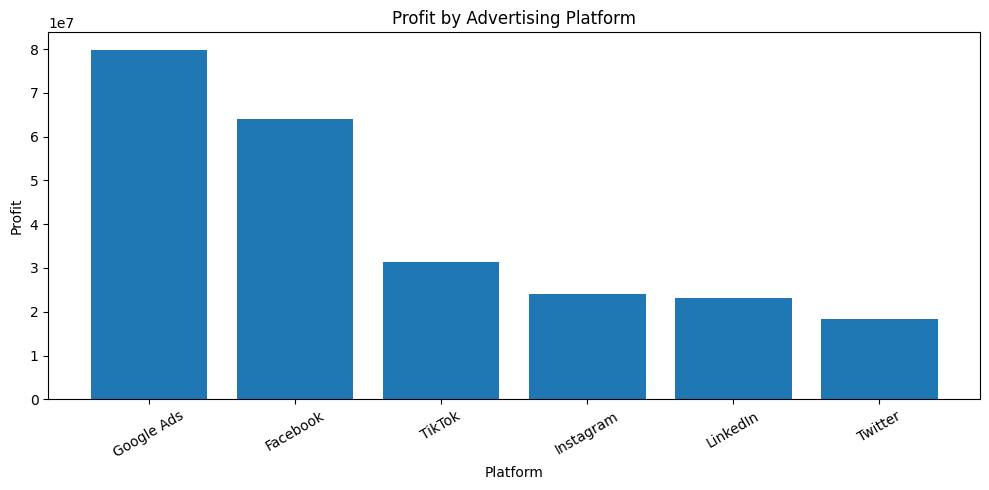

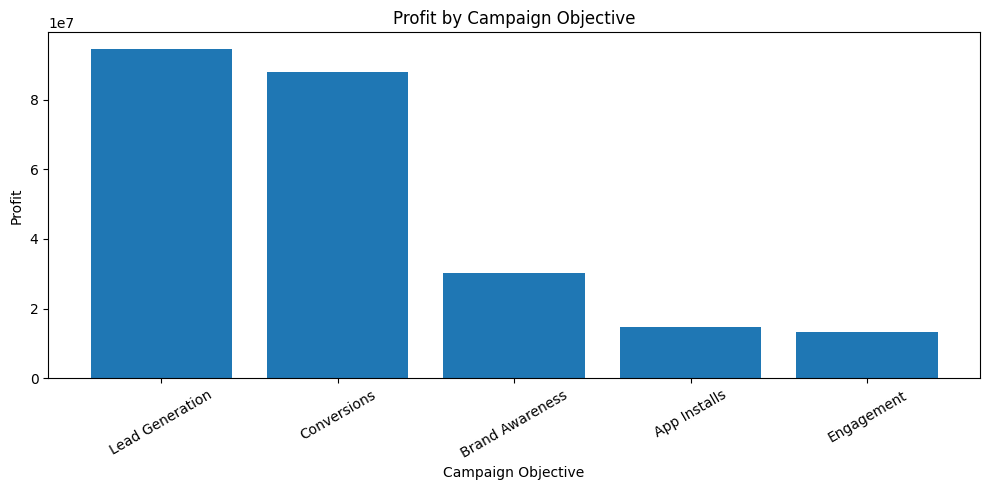

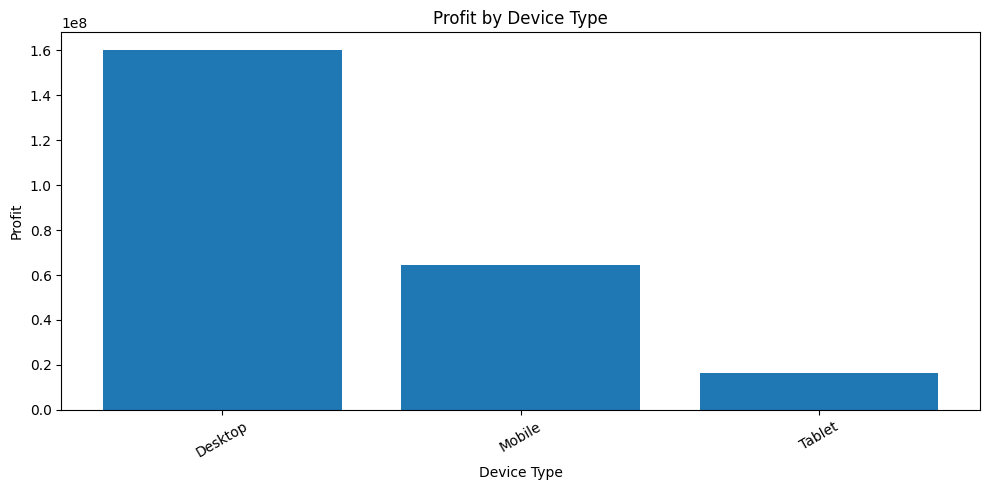

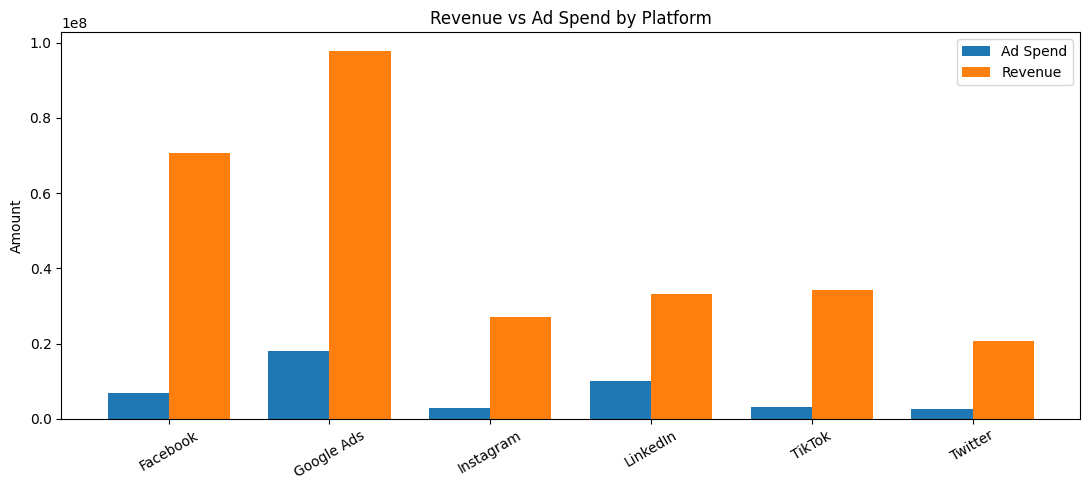

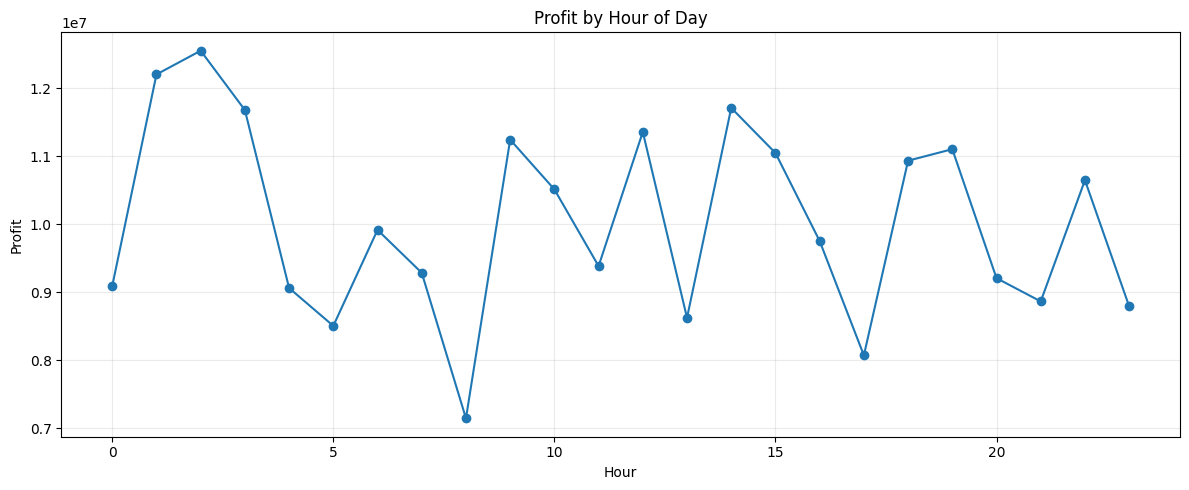

Charts saved to: charts


In [15]:
print("\n" + "=" * 80)
print("CREATING CHARTS")
print("=" * 80)

OUTPUT_DIR = Path("charts")
OUTPUT_DIR.mkdir(exist_ok=True)

def save_bar(data, x_col, y_col, title, filename, rotation=30):
    plt.figure(figsize=(10, 5))
    plt.bar(data[x_col].astype(str), data[y_col])
    plt.title(title)
    plt.xlabel(x_col.replace("_", " ").title())
    plt.ylabel(y_col.replace("_", " ").title())
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()
    plt.close()

# Platform profit
tmp = platform_analysis.sort_values("profit", ascending=False)
save_bar(tmp, "platform", "profit", "Profit by Advertising Platform",
         "01_profit_by_platform.png")

# Objective profit
tmp = objective_analysis.sort_values("profit", ascending=False)
save_bar(tmp, "campaign_objective", "profit", "Profit by Campaign Objective",
         "02_profit_by_campaign_objective.png")

# Device profit
tmp = device_analysis.sort_values("profit", ascending=False)
save_bar(tmp, "device_type", "profit", "Profit by Device Type",
         "03_profit_by_device.png")

# Revenue vs spend
x = np.arange(len(platform_analysis))
width = 0.38

plt.figure(figsize=(11, 5))
plt.bar(x - width/2, platform_analysis["spend"], width, label="Ad Spend")
plt.bar(x + width/2, platform_analysis["revenue"], width, label="Revenue")
plt.xticks(x, platform_analysis["platform"].astype(str), rotation=30)
plt.title("Revenue vs Ad Spend by Platform")
plt.ylabel("Amount")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_revenue_vs_spend_platform.png", dpi=150)
plt.show()
plt.close()

# Hourly profit if available
if "hour_of_day" in df.columns:
    hour_analysis = performance_by_dimension("hour_of_day").sort_values("hour_of_day")
    plt.figure(figsize=(12, 5))
    plt.plot(hour_analysis["hour_of_day"], hour_analysis["profit"], marker="o")
    plt.title("Profit by Hour of Day")
    plt.xlabel("Hour")
    plt.ylabel("Profit")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "05_profit_by_hour.png", dpi=150)
    plt.show()
    plt.close()

print(f"Charts saved to: {OUTPUT_DIR}")


## 16. AUTOMATIC BUSINESS INSIGHTS


In [16]:
print("\n" + "=" * 80)
print("KEY BUSINESS INSIGHTS")
print("=" * 80)

best_platform_row = platform_analysis.loc[platform_analysis["ROAS"].idxmax()]
best_objective_row = objective_analysis.loc[objective_analysis["profit"].idxmax()]
best_device_row = device_analysis.loc[device_analysis["ROAS"].idxmax()]
best_placement_row = placement_analysis.loc[placement_analysis["ROAS"].idxmax()]

print(
    f"1. Best platform by ROAS: {best_platform_row['platform']} "
    f"({best_platform_row['ROAS']:.2f}x)."
)
print(
    f"2. Most profitable campaign objective: {best_objective_row['campaign_objective']} "
    f"(profit {best_objective_row['profit']:,.2f})."
)
print(
    f"3. Best device by ROAS: {best_device_row['device_type']} "
    f"({best_device_row['ROAS']:.2f}x)."
)
print(
    f"4. Best ad placement by ROAS: {best_placement_row['ad_placement']} "
    f"({best_placement_row['ROAS']:.2f}x)."
)

if "hour_of_day" in df.columns:
    hour_analysis = performance_by_dimension("hour_of_day")
    best_hour = hour_analysis.loc[hour_analysis["profit"].idxmax(), "hour_of_day"]
    print(f"5. Highest-profit hour: {best_hour}:00.")

loss_pct = safe_divide(len(loss_campaigns), len(df)) * 100
print(f"6. Loss-making campaigns: {loss_pct:.2f}% of all campaigns.")
print(f"7. Overall ROAS: {overall_roas:.2f}x.")
print(f"8. Total profit: {total_profit:,.2f}.")

print("\nAnalysis completed successfully — no categorical text is used in numeric statistics.")



KEY BUSINESS INSIGHTS
1. Best platform by ROAS: TikTok (11.18x).
2. Most profitable campaign objective: Lead Generation (profit 94,572,636.33).
3. Best device by ROAS: Desktop (10.40x).
4. Best ad placement by ROAS: Sidebar (7.99x).
5. Highest-profit hour: 2:00.
6. Loss-making campaigns: 21.69% of all campaigns.
7. Overall ROAS: 6.54x.
8. Total profit: 240,702,044.68.

Analysis completed successfully — no categorical text is used in numeric statistics.


## Final Portfolio Summary

This project demonstrates:
- Data cleaning and validation
- Marketing KPI analysis
- Platform and campaign objective analysis
- Audience segmentation
- Device and placement analysis
- Creative performance analysis
- Time-based campaign analysis
- Profit and ROAS optimization
- Business-focused visualizations

### Recommended next step
Use these results to build the 3-page Power BI dashboard:
1. Executive Overview
2. Campaign Performance
3. Audience & Creative Intelligence
